Importing libraries and functions from other files

In [1]:
import numpy as np
from model.grid_init import *
from model.parameters import get_default_parameters
from model.population_growth import *
from visualization.plots import plot_3d
from visualization.animation import animate_heatmap_section
from ipywidgets import *
import matplotlib.pyplot as plt

Fetching parameters

In [2]:
params = get_default_parameters()
time_steps = 5000 # 50 hours

Perfusion simulation, based on continuously delivering the drug at a certain rate and Dosing simulation, based on delivering a dose at every interval of time

The simulation is based on the following PDEs :
For the drug diffusion : The first term explains the diffusion, the second term explains the decay of the product, and the last term is the uptake of the drug by the cancer cells\
$\frac{\partial C}{\partial t} = D {\nabla^2 C} - D_{rate} C - U_{rate} C D$ \
For the density of cancer : The first term is the logistic differential equation, the second term explains the death by drug and the third term is borrowed from the diffusion PDE and explains the proliferation of cancer cells in nearby spots \
$\frac{\partial D}{\partial t} = r D (1 - D) - \alpha C D + M_{rate} \nabla^2 D$

In [ ]:
def simulate_perfusion(params, time_steps):
    density_grid, concentration_grid = initialize_density_blob(params.grid_dims, params.blob_centers, params.blob_std_dev)
    drug_source_grid = drug_source(params.source_concentration, params.source_positions, params.grid_dims)
    concentration_grid += drug_source_grid * params.dt
    density_grid_history = [density_grid.copy()]
    concentration_grid_history = [concentration_grid.copy()]

    for t in range(time_steps):
        concentration_grid = update_concentration_3d_perfusion(concentration_grid,density_grid, drug_source_grid,
                                                             params.diffusion_rate, params.dt, params.dx, params.decay, params.beta)
        drug_effect_grid = drug_effect(concentration_grid, params.EC50, params.hill_coefficient)
        density_grid = update_density_3d(density_grid, drug_effect_grid, params.r, params.alpha, params.dt, params.dx, params.movement_rate)
        density_grid_history.append(density_grid.copy())
        concentration_grid_history.append(concentration_grid.copy())

    return density_grid_history, concentration_grid_history

In [ ]:
def simulate_intervals(params, time_steps):
    density_grid, concentration_grid = initialize_density_blob(params.grid_dims, params.blob_centers, params.blob_std_dev)
    concentration_grid = add_dose(concentration_grid, params.source_concentration, params.source_positions)
    density_grid_history = [density_grid.copy()]
    concentration_grid_history = [concentration_grid.copy()]

    for t in range(time_steps):
        if t % round(params.dose_interval / params.dt) == 0:
            concentration_grid = add_dose(concentration_grid, params.source_concentration, params.source_positions)
        concentration_grid = update_concentration_3d(concentration_grid, density_grid, params.diffusion_rate,
                                                      params.dt, params.dx, params.decay, params.beta)
        drug_effect_grid = drug_effect(concentration_grid, params.EC50, params.hill_coefficient)
        density_grid = update_density_3d(density_grid, drug_effect_grid, params.r, params.alpha, params.dt, params.dx, params.movement_rate)
        density_grid_history.append(density_grid.copy())
        concentration_grid_history.append(concentration_grid.copy())

    return density_grid_history, concentration_grid_history

In [5]:
density_grid_history_perfusion, concentration_grid_history_perfusion = simulate_perfusion(params, time_steps)
density_grid_history_intervals, concentration_grid_history_intervals = simulate_intervals(params, time_steps)

Plotting results 

In [6]:
perfusion_history = {
    'density': density_grid_history_perfusion,
    'concentration': concentration_grid_history_perfusion
}
intervals_history = {
    'density': density_grid_history_intervals,
    'concentration': concentration_grid_history_intervals
}

In [7]:
def plotter(timestep, history):
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(history['concentration'][timestep][:, :, params.grid_dims[2]//2], cmap='inferno', vmin=0, vmax=0.5)
    plt.title(f'Concentration at Timestep {timestep}')
    plt.colorbar(label='Concentration (mM)')
    plt.subplot(1, 2, 2)
    plt.imshow(history['density'][timestep][:, :, params.grid_dims[2]//2], cmap='inferno', vmin=0, vmax=1)
    plt.title(f'Density at Timestep {timestep}')
    plt.colorbar(label='Density (normalized)')
    plt.show()

Animation of section at mid height ( mid z )

In [ ]:
# Perfusion animation
interactive(plotter, timestep= Play(min=0, max=time_steps, value=0, interval=25), 
            history = fixed(perfusion_history))

interactive(children=(Play(value=0, description='timestep', interval=25, max=5000), Output()), _dom_classes=('…

In [ ]:
# Dosing animation
interactive(plotter, timestep= Play(min=0, max=time_steps, value=0, interval=25), 
            history = fixed(intervals_history))

interactive(children=(Play(value=0, description='timestep', interval=25, max=5000), Output()), _dom_classes=('…

3D plot of the final tumor density and drug concentration

/Users/rayenezanina/Desktop/Project/Tumor simulation/visualization/plots.py:37: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  ax1.scatter(X.flatten(), Y.flatten(), Z.flatten(), c=colors1, cmap='inferno', vmin=0, vmax=1)
/Users/rayenezanina/Desktop/Project/Tumor simulation/visualization/plots.py:51: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  ax2.scatter(X.flatten(), Y.flatten(), Z.flatten(), c=colors2, cmap='inferno', vmin=0, vmax=concentration_grid.max())


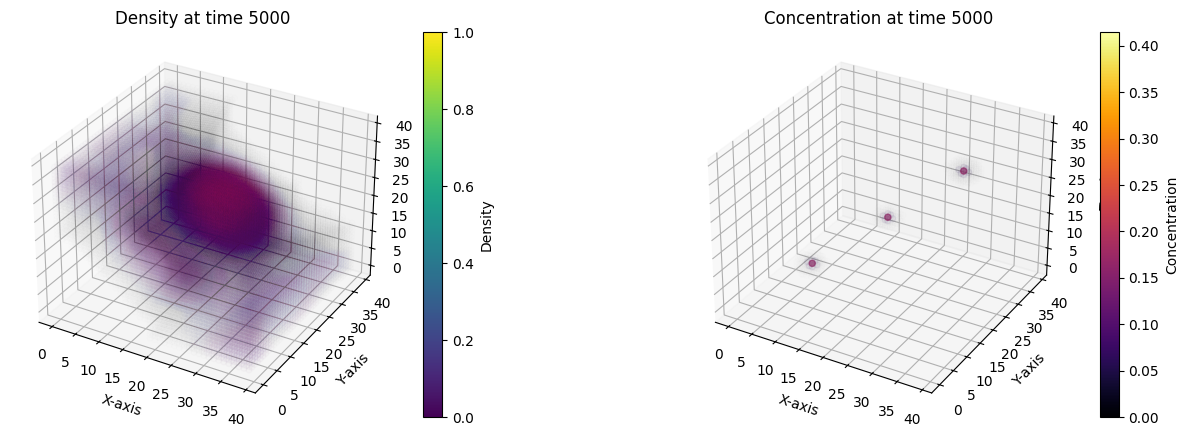

In [ ]:
# Perfusion final plot
plot_3d(density_grid_history_perfusion[-1], concentration_grid_history_perfusion[-1], time_steps)

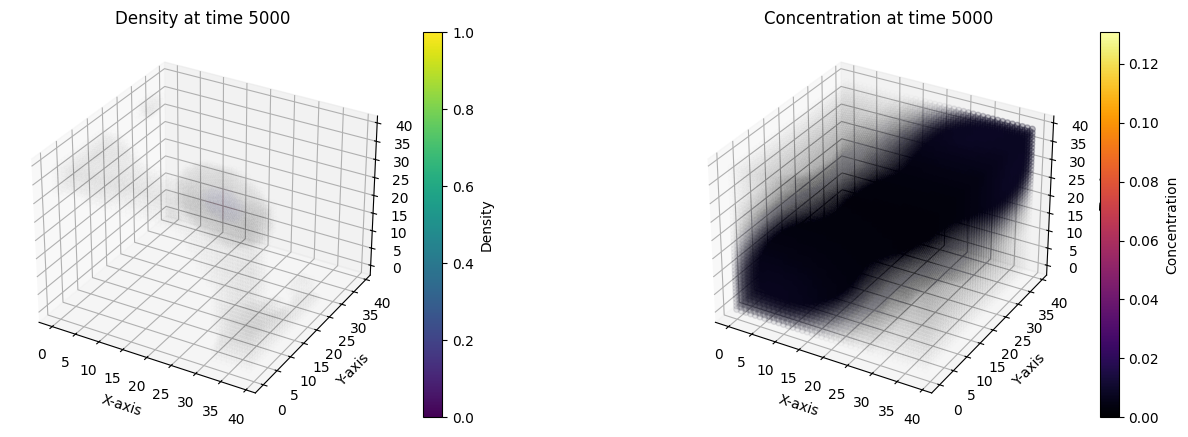

In [ ]:
# Dosing final plot
plot_3d(density_grid_history_intervals[-1], concentration_grid_history_intervals[-1], time_steps)